=============================================================================
Notebook 1: DEM Preparation and Alignment
=============================================================================
Downloads SRTM, loads glacier shapefiles and additional DEMs, reprojects
everything to a common CRS and grid, and saves aligned DEMs for Notebook 2.

This workflow is fully open-source (rasterio, rioxarray, GDAL, pyproj).
No ArcPy or commercial software required.

INPUTS:
  - SRTM tiles (downloaded via earthaccess)
  - Your DEM files (1954 IGM, 2024 drone DEMs)
  - Glacier shapefiles (DGA 2000 and 2019)

OUTPUTS:
  - aligned_dems/<name>_aligned.tif  ← all DEMs on the same CRS + grid

=============================================================================

In [1]:
# ------------------------------------------------------------------------------
# Imports
# ------------------------------------------------------------------------------
import os
import zipfile
import numpy as np
import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
import rioxarray as rxr
import geopandas as gpd
import matplotlib.pyplot as plt
import earthaccess

In [2]:
# ------------------------------------------------------------------------------
# USER VARIABLES
# ------------------------------------------------------------------------------
# Target CRS: WGS84 / UTM Zone 19S (appropriate for Nevados de Chillán)
TARGET_CRS = "EPSG:32719"

# Bounding box for SRTM download: (west, south, east, north)
# Nevados de Chillán ~36.9°S, 71.4°W
BOUNDING_BOX = (-71.4, -36.8, -71.2, -36.6)

# Folder for raw SRTM tiles
SRTM_RAW_DIR = "./srtm_data"

# Folder containing your non-SRTM DEMs
DEM_FOLDER = "example_data_Nevados/Nevados_DEMs"

# DEM filenames (must be in DEM_FOLDER)
# The SRTM_2000.tif here is the merged/clipped SRTM tile — see Step 1 below.
DEM_FILES = {
    "CerroBlanco_2024": "CerroBlanco_2024.tif",
    "LasTermas_2024":   "LasTermas_2024.tif",
    "IGM_1954":         "IGM_1954.tif",
    "Pleiades_2025":    "Pleiades_2025.tif",
    "ASTER_2004":       "ASTER_2004.tif",
    "ASTER_2004b":      "ASTER_2004b.tif",
    "ASTER_2005":       "ASTER_2005.tif",
    "ASTER_2006":       "ASTER_2006.tif",
    "ASTER_2007":       "ASTER_2007.tif",
    "ASTER_2008":       "ASTER_2008.tif",
    "ASTER_2014":       "ASTER_2014.tif",
    "ASTER_2015":       "ASTER_2015.tif",
    "ASTER_2018":       "ASTER_2018.tif",
    # SRTM_2000 is built from downloaded tiles in Step 1 — added automatically
}

# Glacier shapefile paths
GLACIER_2000_PATH = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp"
GLACIER_2019_PATH = "example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"

# Output folder for aligned DEMs
OUTPUT_FOLDER = "aligned_dems"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

In [3]:
# ==============================================================================
# Step 1: Download and prepare SRTM DEM
# ==============================================================================
print("="*60)
print("Step 1: SRTM download and preparation")
print("="*60)

os.makedirs(SRTM_RAW_DIR, exist_ok=True)

Step 1: SRTM download and preparation


In [4]:
# Only download if the directory is empty
if not any(f.endswith((".hgt", ".tif")) for f in os.listdir(SRTM_RAW_DIR)):
    print("Logging in to EarthAccess...")
    earthaccess.login()

    results = earthaccess.search_data(
        short_name   = "SRTMGL1",
        bounding_box = BOUNDING_BOX,
    )
    print(f"Found {len(results)} SRTM granule(s) covering the bounding box.")

    for granule in results:
        earthaccess.download(granule, SRTM_RAW_DIR)
else:
    print(f"SRTM files already present in {SRTM_RAW_DIR}, skipping download.")

SRTM files already present in ./srtm_data, skipping download.


In [5]:
# Unzip any .zip files
for fname in os.listdir(SRTM_RAW_DIR):
    if fname.endswith(".zip"):
        zip_path = os.path.join(SRTM_RAW_DIR, fname)
        extracted_name = fname.replace(".zip", "")
        if not os.path.exists(os.path.join(SRTM_RAW_DIR, extracted_name)):
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(SRTM_RAW_DIR)
            print(f"  Unzipped: {fname}")
        else:
            print(f"  Already unzipped: {fname}")

  Unzipped: N58W134.SRTMGL1.hgt.zip
  Unzipped: N59W134.SRTMGL1.hgt.zip
  Unzipped: N58W135.SRTMGL1.hgt.zip
  Unzipped: N59W135.SRTMGL1.hgt.zip
  Unzipped: S37W072.SRTMGL1.hgt.zip


In [6]:
# Collect SRTM tile paths (.hgt files)
srtm_tiles = [
    os.path.join(SRTM_RAW_DIR, f)
    for f in os.listdir(SRTM_RAW_DIR)
    if f.endswith(".hgt")
]
print(f"\nFound {len(srtm_tiles)} SRTM tile(s): {[os.path.basename(t) for t in srtm_tiles]}")

# Merge tiles and clip to bounding box, saving as SRTM_2000.tif in DEM_FOLDER
srtm_out_path = os.path.join(DEM_FOLDER, "SRTM_2000.tif")


Found 5 SRTM tile(s): ['N58W134.hgt', 'N58W135.hgt', 'N59W134.hgt', 'N59W135.hgt', 'S37W072.hgt']


In [7]:
if not os.path.exists(srtm_out_path):
    print("Merging SRTM tiles...")
    tile_datasets = [rasterio.open(t) for t in srtm_tiles]
    merged, merged_transform = rio_merge(tile_datasets)
    merged_crs  = tile_datasets[0].crs
    merged_meta = tile_datasets[0].meta.copy()
    merged_meta.update({
        "driver": "GTiff",
        "height": merged.shape[1],
        "width":  merged.shape[2],
        "transform": merged_transform,
        "crs": merged_crs,
    })
    for ds in tile_datasets:
        ds.close()

    # Clip to bounding box
    from rasterio.transform import array_bounds
    from rasterio.windows import from_bounds

    with rasterio.MemoryFile() as memfile:
        with memfile.open(**merged_meta) as mem:
            mem.write(merged)
            west, south, east, north = BOUNDING_BOX
            window = from_bounds(west, south, east, north,
                                 transform=merged_transform)
            clipped = mem.read(window=window)
            clip_transform = mem.window_transform(window)

    clip_meta = merged_meta.copy()
    clip_meta.update({
        "height": clipped.shape[1],
        "width":  clipped.shape[2],
        "transform": clip_transform,
    })
    os.makedirs(DEM_FOLDER, exist_ok=True)
    with rasterio.open(srtm_out_path, "w", **clip_meta) as dst:
        dst.write(clipped)
    print(f"  SRTM merged and clipped → {srtm_out_path}")
else:
    print(f"  SRTM_2000.tif already exists at {srtm_out_path}, skipping merge.")

  SRTM_2000.tif already exists at example_data_Nevados/Nevados_DEMs/SRTM_2000.tif, skipping merge.


In [8]:
# Add SRTM to the DEM dictionary
DEM_FILES["SRTM_2000"] = "SRTM_2000.tif"

In [9]:
# ==============================================================================
# Step 2: Load and inspect glacier shapefiles
# ==============================================================================
print("\n" + "="*60)
print("Step 2: Load glacier shapefiles")
print("="*60)

glacier_2000_gdf = gpd.read_file(GLACIER_2000_PATH)
glacier_2019_gdf = gpd.read_file(GLACIER_2019_PATH)

print(f"DGA 2000 outlines: {len(glacier_2000_gdf)} polygons, CRS: {glacier_2000_gdf.crs}")
print(f"DGA 2019 outlines: {len(glacier_2019_gdf)} polygons, CRS: {glacier_2019_gdf.crs}")
print(glacier_2000_gdf.head(3))


Step 2: Load glacier shapefiles
DGA 2000 outlines: 28 polygons, CRS: EPSG:32719
DGA 2019 outlines: 993 polygons, CRS: EPSG:32719
   Id      COD_GLA NOMBRE             CLASIFICA  REGION    COMUNA   DATUM  \
0  10  CL108130010    S/N  GLACIAR DE MONTAï¿½A  BIOBIO     PINTO  WGS 84   
1   3  CL108100003    S/N            GLACIARETE  BIOBIO  COIHUECO  WGS 84   
2   2  CL108100002    S/N            GLACIARETE  BIOBIO  COIHUECO  WGS 84   

    HUSO    ESTE    NORTE  ... ORIENABLAC ORIENTA CLAS_WGI  \
0  19SUR  288487  5915779  ...       None       S        6   
1  19SUR  288834  5916614  ...       None       N        7   
2  19SUR  289865  5916798  ...       None       E        7   

             CLAS_2_CUB  ZONA_GLACI HMEDIANA PENDIENTE ERROR_KM2 ERROR_PORC  \
0  GLACIAR DE MONTAï¿½A    ZONA SUR   2907.0   26.7534  0.026888    19.3442   
1            GLACIARETE    ZONA SUR   3108.0    6.7916  0.009526    38.1054   
2            GLACIARETE    ZONA SUR   2741.0   24.1722  0.010854    47.1926

In [13]:
# ==============================================================================
# Step 3: Reproject and align all DEMs to SRTM reference grid
# ==============================================================================
# All DEMs are:
#   1. Reprojected to TARGET_CRS (EPSG:32719, UTM 19S)
#   2. Resampled to match the SRTM_2000 pixel grid using bilinear interpolation
#
# The reference DEM (SRTM) is reprojected first with EXACTLY 30m square pixels
# by snapping to a clean grid origin. All other DEMs then use reproject_match()
# which inherits the clean 30m transform exactly, avoiding floating point drift
# (e.g. 30.00000000022571 x 30.00000000022562) that breaks xDEM terrain tools.
#
# NOTE on the IGM 1954 DEM:
#   If your 1954 DEM uses PSAD56 (the old South American datum), make sure
#   its CRS is correctly set before this step. If rasterio reads it as
#   undefined, assign it explicitly:
#       dem.rio.write_crs("EPSG:24879", inplace=True)  # PSAD56 UTM 19S
#   pyproj / PROJ will then apply the correct datum shift to WGS84.

from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_origin
from rasterio.crs import CRS as RasterioCRS

print("\n" + "="*60)
print("Step 3: Reproject and align DEMs")
print("="*60)

# --- Load and reproject reference DEM with exactly 30m square pixels ---
ref_path = os.path.join(DEM_FOLDER, "SRTM_2000.tif")
print(f"\nReprojecting reference DEM with exactly 30m square pixels: {ref_path}")

dst_crs   = RasterioCRS.from_epsg(32719)
EXACT_RES = 30.0

with rasterio.open(ref_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    # Snap origin to nearest clean 30m grid point
    x_origin = round(transform.c / EXACT_RES) * EXACT_RES
    y_origin = round(transform.f / EXACT_RES) * EXACT_RES
    clean_transform = from_origin(x_origin, y_origin, EXACT_RES, EXACT_RES)

    # Compute output dimensions
    clean_width  = int(round((transform.c + transform.a * width  - x_origin) / EXACT_RES)) + 1
    clean_height = int(round((y_origin - (transform.f + transform.e * height)) / EXACT_RES)) + 1

    profile = src.profile.copy()
    profile.update(
        crs       = dst_crs,
        transform = clean_transform,
        width     = clean_width,
        height    = clean_height,
        dtype     = "float32",
        nodata    = np.nan,
        count     = 1,
    )

    ref_data = np.empty((1, clean_height, clean_width), dtype=np.float32)
    reproject(
        source        = rasterio.band(src, 1),
        destination   = ref_data,
        src_transform = src.transform,
        src_crs       = src.crs,
        dst_transform = clean_transform,
        dst_crs       = dst_crs,
        resampling    = Resampling.bilinear,
    )

ref_aligned_path = os.path.join(OUTPUT_FOLDER, "SRTM_2000_aligned.tif")
with rasterio.open(ref_aligned_path, "w", **profile) as dst:
    dst.write(ref_data)

# Load as rioxarray — used as reproject_match target for all other DEMs
reference = rxr.open_rasterio(ref_aligned_path, masked=True).squeeze()
res = [abs(r) for r in reference.rio.resolution()]
print(f"  CRS: {reference.rio.crs}")
print(f"  Resolution: {res} m")
print(f"  Shape: {reference.shape}")
print(f"  Saved: {ref_aligned_path}")

# --- Reproject and align all other DEMs to reference grid ---
for dem_name, dem_filename in DEM_FILES.items():
    if dem_name == "SRTM_2000":
        continue

    dem_path = os.path.join(DEM_FOLDER, dem_filename)
    out_path = os.path.join(OUTPUT_FOLDER, f"{dem_name}_aligned.tif")

    if os.path.exists(out_path):
        print(f"\n  {dem_name}: already aligned, skipping.")
        continue

    print(f"\n  Processing: {dem_name}")
    dem = rxr.open_rasterio(dem_path, masked=True).squeeze()

    # Clean elevation artifacts — mask values outside plausible range.
    # Catches ASTER stereo artifacts (~-500m) not handled by nodata masking.
    # No valid elevations below 0m or above 7000m at Nevados de Chillán.
    dem = dem.where((dem > 0) & (dem < 7000))

    print(f"    Input CRS: {dem.rio.crs}, res: {[abs(r) for r in dem.rio.resolution()]}")

    # Special case: IGM 1954 — check CRS is assigned
    if dem_name == "IGM_1954" and dem.rio.crs is None:
        print("    WARNING: IGM_1954 has no CRS. Assigning PSAD56 UTM 19S (EPSG:24879).")
        dem = dem.rio.write_crs("EPSG:24879")

    # Reproject to target CRS then snap to reference grid
    dem_reprojected = dem.rio.reproject(TARGET_CRS)
    dem_aligned = dem_reprojected.rio.reproject_match(
        reference,
        resampling=Resampling.bilinear
    )

    res_out = [abs(r) for r in dem_aligned.rio.resolution()]
    print(f"    Output CRS: {dem_aligned.rio.crs}, res: {res_out} m")
    dem_aligned.rio.to_raster(out_path)
    print(f"    Saved: {out_path}")


Step 3: Reproject and align DEMs

Reprojecting reference DEM with exactly 30m square pixels: example_data_Nevados/Nevados_DEMs/SRTM_2000.tif
  CRS: EPSG:32719
  Resolution: [30.0, 30.0] m
  Shape: (3779, 3084)
  Saved: aligned_dems/SRTM_2000_aligned.tif

  CerroBlanco_2024: already aligned, skipping.

  LasTermas_2024: already aligned, skipping.

  IGM_1954: already aligned, skipping.

  Pleiades_2025: already aligned, skipping.

  ASTER_2004: already aligned, skipping.

  ASTER_2004b: already aligned, skipping.

  ASTER_2005: already aligned, skipping.

  ASTER_2006: already aligned, skipping.

  ASTER_2007: already aligned, skipping.

  ASTER_2008: already aligned, skipping.

  ASTER_2014: already aligned, skipping.

  ASTER_2015: already aligned, skipping.

  ASTER_2018: already aligned, skipping.


In [14]:
# ==============================================================================
# Step 4: Verification — print CRS and resolution for all aligned DEMs
# ==============================================================================
print("\n" + "="*60)
print("Step 4: Alignment verification")
print("="*60)

print(f"{'DEM':<25} {'CRS':<15} {'X res (m)':<12} {'Y res (m)':<12} {'Shape'}")
for dem_name in DEM_FILES:
    aligned_path = os.path.join(OUTPUT_FOLDER, f"{dem_name}_aligned.tif")
    if not os.path.exists(aligned_path):
        print(f"  {dem_name:<23} NOT FOUND")
        continue
    with rasterio.open(aligned_path) as src:
        xres = abs(src.transform.a)
        yres = abs(src.transform.e)
        shape = (src.height, src.width)
        crs_str = str(src.crs).split(":")[-1] if src.crs else "None"
    print(f"  {dem_name:<23} EPSG:{crs_str:<10} {xres:<12.2f} {yres:<12.2f} {shape}")


Step 4: Alignment verification
DEM                       CRS             X res (m)    Y res (m)    Shape
  CerroBlanco_2024        EPSG:32719      30.00        30.00        (3779, 3084)
  LasTermas_2024          EPSG:32719      30.00        30.00        (3779, 3084)
  IGM_1954                EPSG:32719      30.00        30.00        (3779, 3084)
  Pleiades_2025           EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2004              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2004b             EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2005              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2006              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2007              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2008              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2014              EPSG:32719      30.00        30.00        (3779, 3084)
  A


Generating overview plots...
Found 14 aligned DEMs: ['ASTER_2004', 'ASTER_2004b', 'ASTER_2005', 'ASTER_2006', 'ASTER_2007', 'ASTER_2008', 'ASTER_2014', 'ASTER_2015', 'ASTER_2018', 'CerroBlanco_2024', 'IGM_1954', 'LasTermas_2024', 'Pleiades_2025', 'SRTM_2000']


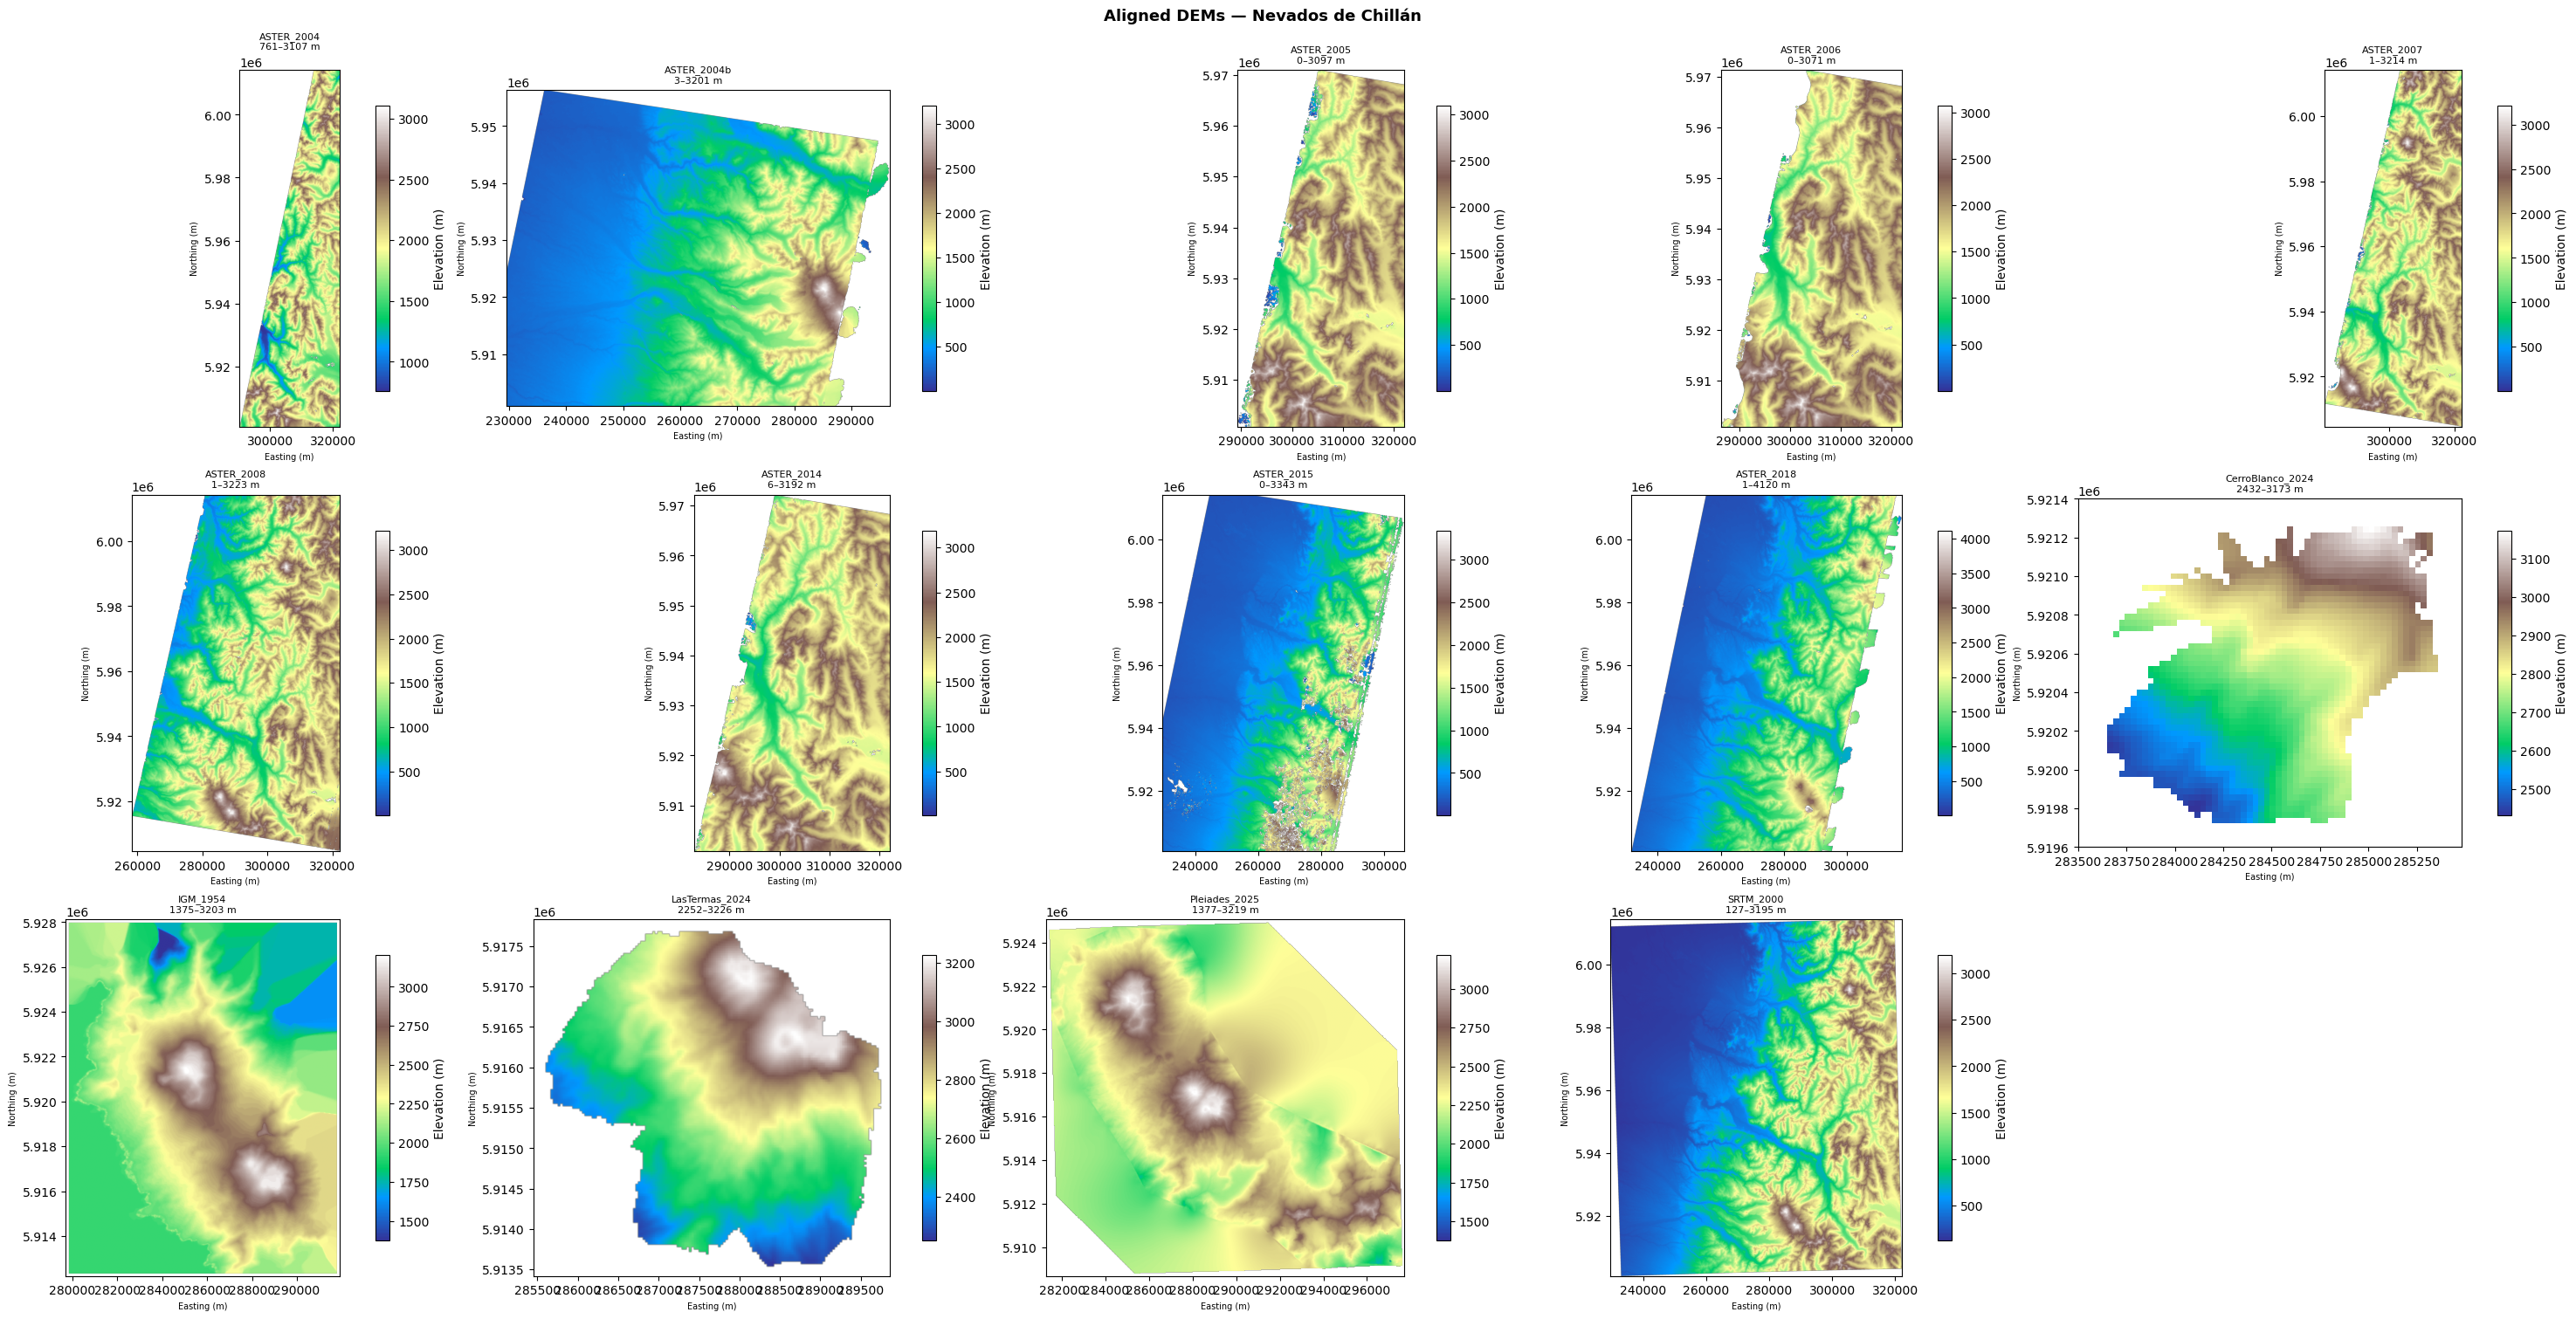

Saved: aligned_dems/aligned_dem_overview.png


In [17]:
# ==============================================================================
# Step 5: Quick visualization
# ==============================================================================
print("\nGenerating overview plots...")

import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt

# Directly list all aligned files in the output folder
available = [
    f.replace("_aligned.tif", "")
    for f in os.listdir(OUTPUT_FOLDER)
    if f.endswith("_aligned.tif")
]
available = sorted(available)
print(f"Found {len(available)} aligned DEMs: {available}")

if len(available) == 0:
    print("No aligned DEMs found — run Steps 1-4 first.")
else:
    ncols = 5
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(6 * ncols, 5 * nrows),
                              constrained_layout=True)
    axes = np.array(axes).flatten()

    for i, dem_name in enumerate(available):
        ax   = axes[i]
        path = os.path.join(OUTPUT_FOLDER, f"{dem_name}_aligned.tif")
        with rasterio.open(path) as src:
            data   = src.read(1).astype(float)
            nodata = src.nodata
            if nodata is not None:
                data[data == nodata] = np.nan
            data[data > 1e10] = np.nan
            data[data < 0]    = np.nan
            b = src.bounds
            t = src.transform

        valid_rows, valid_cols = np.where(np.isfinite(data))
        if len(valid_rows) == 0:
            ax.set_title(f"{dem_name}\n(no valid data)")
            ax.axis('off')
            continue

        r0 = max(valid_rows.min() - 5, 0)
        r1 = min(valid_rows.max() + 5, data.shape[0])
        c0 = max(valid_cols.min() - 5, 0)
        c1 = min(valid_cols.max() + 5, data.shape[1])

        left   = b.left + c0 * t.a
        right  = b.left + c1 * t.a
        top    = b.top  + r0 * t.e
        bottom = b.top  + r1 * t.e

        im = ax.imshow(data[r0:r1, c0:c1], cmap="terrain",
                       extent=[left, right, bottom, top], origin="upper")
        plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
        ax.set_title(f"{dem_name}\n{np.nanmin(data):.0f}–{np.nanmax(data):.0f} m",
                     fontsize=8)
        ax.set_xlabel("Easting (m)", fontsize=7)
        ax.set_ylabel("Northing (m)", fontsize=7)

    for j in range(len(available), len(axes)):
        axes[j].axis('off')

    fig.suptitle("Aligned DEMs — Nevados de Chillán", fontsize=13, fontweight="bold")
    fig.savefig(os.path.join(OUTPUT_FOLDER, "aligned_dem_overview.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {OUTPUT_FOLDER}/aligned_dem_overview.png")

In [16]:
for ax, dem_name in zip(axes, DEM_FILES):
    aligned_path = os.path.join(OUTPUT_FOLDER, f"{dem_name}_aligned.tif")
    if not os.path.exists(aligned_path):
        ax.set_title(f"{dem_name}\n(not found)")
        continue
    with rasterio.open(aligned_path) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        extent = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]
    im = ax.imshow(data, cmap="terrain", extent=extent, origin="upper")
    plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
    ax.set_title(dem_name, fontsize=11)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

fig.suptitle("Aligned DEMs — Nevados de Chillán", fontsize=13, fontweight="bold")
fig.savefig(os.path.join(OUTPUT_FOLDER, "aligned_dem_overview.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("\nNotebook 1 complete.")
print(f"Aligned DEMs saved to: {OUTPUT_FOLDER}/")
print("Pass aligned_dems/ folder to Notebook 2 for co-registration.")

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_59633/3363409233.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 2400x500 with 9 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_59633/3363409233.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 2400x500 with 10 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_59633/3363409233.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 2400x500 with 11 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax, label="Elevation (m)", shrink=0.8)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_59633/3363409233.py:14: UserWarni

<Figure size 640x480 with 0 Axes>


Notebook 1 complete.
Aligned DEMs saved to: aligned_dems/
Pass aligned_dems/ folder to Notebook 2 for co-registration.


## Pulling in Hugonnet DEMs

In [ ]:
import pandas as pd
from datetime import datetime

granules = """19S/AST_L1A_00301012008145154
19S/AST_L1A_00301052018144606
19S/AST_L1A_00301102008144603
19S/AST_L1A_00301102014144550
19S/AST_L1A_00301102014144608
19S/AST_L1A_00301122009144629
19S/AST_L1A_00301122018145217
19S/AST_L1A_00301142013145211
19S/AST_L1A_00301162011145727
19S/AST_L1A_00301212018144548
19S/AST_L1A_00301212018144606
19S/AST_L1A_00301232013144551
19S/AST_L1A_00301262008144545
19S/AST_L1A_00301262008144603
19S/AST_L1A_00301292001150350
19S/AST_L1A_00301292001150408
19S/AST_L1A_00301292015144601
19S/AST_L1A_00301292015144619
19S/AST_L1A_00302112014144540
19S/AST_L1A_00302112014144558
19S/AST_L1A_00302182005144503
19S/AST_L1A_00302212006144456
19S/AST_L1A_00302212015145214
19S/AST_L1A_00302242007144558
19S/AST_L1A_00302242007144616
19S/AST_L1A_00303012018145201
19S/AST_L1A_00303102004145215
19S/AST_L1A_00303262004145213
19S/AST_L1A_00303302008144525
19S/AST_L1A_00303302008144534
19S/AST_L1A_00304062002145327
19S/AST_L1A_00304082017144559
19S/AST_L1A_00304112004145158
19S/AST_L1A_00304132013144623
19S/AST_L1A_00304152017145201
19S/AST_L1A_00304162014144611
19S/AST_L1A_00304182003144607
19S/AST_L1A_00304182003144624
19S/AST_L1A_00304182009144658
19S/AST_L1A_00304262015145225
19S/AST_L1A_00304272004145200
19S/AST_L1A_00305052015144611
19S/AST_L1A_00305052015144629
19S/AST_L1A_00305162019144616
19S/AST_L1A_00307262019145208
19S/AST_L1A_00308212008144626
19S/AST_L1A_00309052019144528
19S/AST_L1A_00309082006145126
19S/AST_L1A_00309102015144640
19S/AST_L1A_00309152017144628
19S/AST_L1A_00309172006144511
19S/AST_L1A_00309172006144528
19S/AST_L1A_00309192010145136
19S/AST_L1A_00309192010145154
19S/AST_L1A_00309212019144526
19S/AST_L1A_00309212019144543
19S/AST_L1A_00309222002144705
19S/AST_L1A_00309222002144723
19S/AST_L1A_00309282016144555
19S/AST_L1A_00309282016144613
19S/AST_L1A_00309302005144459
19S/AST_L1A_00310012017144605
19S/AST_L1A_00310022000150002
19S/AST_L1A_00310032015145213
19S/AST_L1A_00310052001145119
19S/AST_L1A_00310052001145137
19S/AST_L1A_00310062013144536
19S/AST_L1A_00310062013144553
19S/AST_L1A_00310112003144543
19S/AST_L1A_00310112018145252
19S/AST_L1A_00310112018145309
19S/AST_L1A_00310222013144530
19S/AST_L1A_00310222013144548
19S/AST_L1A_00310242017145205
19S/AST_L1A_00310242017145222
19S/AST_L1A_00310252014144621
19S/AST_L1A_00310302010144514
19S/AST_L1A_00310302016144551
19S/AST_L1A_00310302016144608
19S/AST_L1A_00311062010145128
19S/AST_L1A_00311062010145146
19S/AST_L1A_00311092008144605
19S/AST_L1A_00311102014144559
19S/AST_L1A_00311112012145125
19S/AST_L1A_00311122003144624
19S/AST_L1A_00311132015144636
19S/AST_L1A_00311152010144530
19S/AST_L1A_00311152016144608
19S/AST_L1A_00311182017144554
19S/AST_L1A_00311182017144612
19S/AST_L1A_00311202015145228
19S/AST_L1A_00311202015145246
19S/AST_L1A_00311222010145133
19S/AST_L1A_00311232007144524
19S/AST_L1A_00311232007144542
19S/AST_L1A_00311232013144537
19S/AST_L1A_00311282003144635
19S/AST_L1A_00311282003144653
19S/AST_L1A_00311302013145209
19S/AST_L1A_00312012010144523
19S/AST_L1A_00312012010144541
19S/AST_L1A_00312012016144554
19S/AST_L1A_00312012016144612
19S/AST_L1A_00312022017145812
19S/AST_L1A_00312042017144607
19S/AST_L1A_00312072018144549
19S/AST_L1A_00312072018144606
19S/AST_L1A_00312092013144558
19S/AST_L1A_00312112011145136
19S/AST_L1A_00312122014144556
19S/AST_L1A_00312122014144614
19S/AST_L1A_00312152015144558
19S/AST_L1A_00312152015144616
19S/AST_L1A_00312192014145204
19S/AST_L1A_00312192014145221
19S/AST_L1A_00312202011144550
19S/AST_L1A_00312202017144546
19S/AST_L1A_00312202017144604
19S/AST_L1A_00312222006144538
19S/AST_L1A_00312232018144600
19S/AST_L1A_00312282014144552
19S/AST_L1A_00312292012145204""".strip().split('\n')

# Parse dates from granule names
# Format: AST_L1A_003MMDDYYYYHHMMSS
records = []
for g in granules:
    name = g.split('/')[-1]
    date_str = name[11:19]  # MMDDYYYY
    try:
        date = datetime.strptime(date_str, '%m%d%Y')
        records.append({'granule': g, 'date': date, 
                        'year': date.year, 'month': date.month})
    except:
        print(f'Could not parse: {name}')

df = pd.DataFrame(records)

print(f'Total granules: {len(df)}')
print(f'Date range: {df.date.min().date()} to {df.date.max().date()}')
print(f'\nGranules per year:')
print(df.groupby('year').size().to_string())
print(f'\nGranules per month (all years):')
print(df.groupby('month').size().to_string())

Total granules: 122
Date range: 2000-10-02 to 2019-09-21

Granules per year:
year
2000     1
2001     4
2002     3
2003     6
2004     4
2005     2
2006     5
2007     4
2008     8
2009     2
2010     9
2011     3
2012     2
2013    10
2014    12
2015    13
2016     7
2017    12
2018    10
2019     5

Granules per month (all years):
month
1     18
2      7
3      5
4     11
5      3
7      1
8      1
9     15
10    18
11    20
12    23


## we want to focus on Feb and March DEMs, peak ablation: 

In [ ]:
# Filter to Feb-March only
feb_mar = df[df['month'].isin([2, 3])].copy()
feb_mar = feb_mar.sort_values('date')

print(f"Feb-March granules: {len(feb_mar)}")
print(f"\nBy year:")
print(feb_mar.groupby('year').size().to_string())
print(f"\nFull list:")
for _, row in feb_mar.iterrows():
    print(f"  {row['date'].date()}  {row['granule']}")

Feb-March granules: 12

By year:
year
2004    2
2005    1
2006    1
2007    2
2008    2
2014    2
2015    1
2018    1

Full list:
  2004-03-10  19S/AST_L1A_00303102004145215
  2004-03-26  19S/AST_L1A_00303262004145213
  2005-02-18  19S/AST_L1A_00302182005144503
  2006-02-21  19S/AST_L1A_00302212006144456
  2007-02-24  19S/AST_L1A_00302242007144558
  2007-02-24  19S/AST_L1A_00302242007144616
  2008-03-30  19S/AST_L1A_00303302008144525
  2008-03-30  19S/AST_L1A_00303302008144534
  2014-02-11  19S/AST_L1A_00302112014144540
  2014-02-11  19S/AST_L1A_00302112014144558
  2015-02-21  19S/AST_L1A_00302212015145214
  2018-03-01  19S/AST_L1A_00303012018145201


In [ ]:
import earthaccess
from datetime import datetime

earthaccess.login()

bounding_box = (-71.4, -36.9, -71.2, -36.6)

# Search for ASTER L1A scenes over your study area in Feb-March
results = earthaccess.search_data(
    short_name='AST_L1A',
    bounding_box=bounding_box,
    temporal=("2004-03-01", "2004-03-31"),  # start with March 2004
)

print(f"Found {len(results)} granules")
for r in results:
    print(f"\n  {r['meta']['native-id']}")
    for url in r.get('umm', {}).get('RelatedUrls', []):
        if 'browse' in url.get('URL', '').lower() or \
           url.get('Type', '') == 'GET RELATED VISUALIZATION':
            print(f"    BROWSE: {url.get('URL', '')}")

Found 5 granules

  AST_L1A_00403032004144628_20250322002835
    BROWSE: https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/AST_L1A.004/AST_L1A_00403032004144628_20250322002835/AST_L1A_00403032004144628_20250322002835.jpg
    BROWSE: s3://lp-prod-public/AST_L1A.004/AST_L1A_00403032004144628_20250322002835/AST_L1A_00403032004144628_20250322002835.jpg

  AST_L1A_00403102004145224_20250322062727
    BROWSE: https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/AST_L1A.004/AST_L1A_00403102004145224_20250322062727/AST_L1A_00403102004145224_20250322062727.jpg
    BROWSE: s3://lp-prod-public/AST_L1A.004/AST_L1A_00403102004145224_20250322062727/AST_L1A_00403102004145224_20250322062727.jpg

  AST_L1A_00403102004145233_20250322062730
    BROWSE: https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-public/AST_L1A.004/AST_L1A_00403102004145233_20250322062730/AST_L1A_00403102004145233_20250322062730.jpg
    BROWSE: s3://lp-prod-public/AST_L1A.004/AST_L1A_00403102004145233_20250322062730

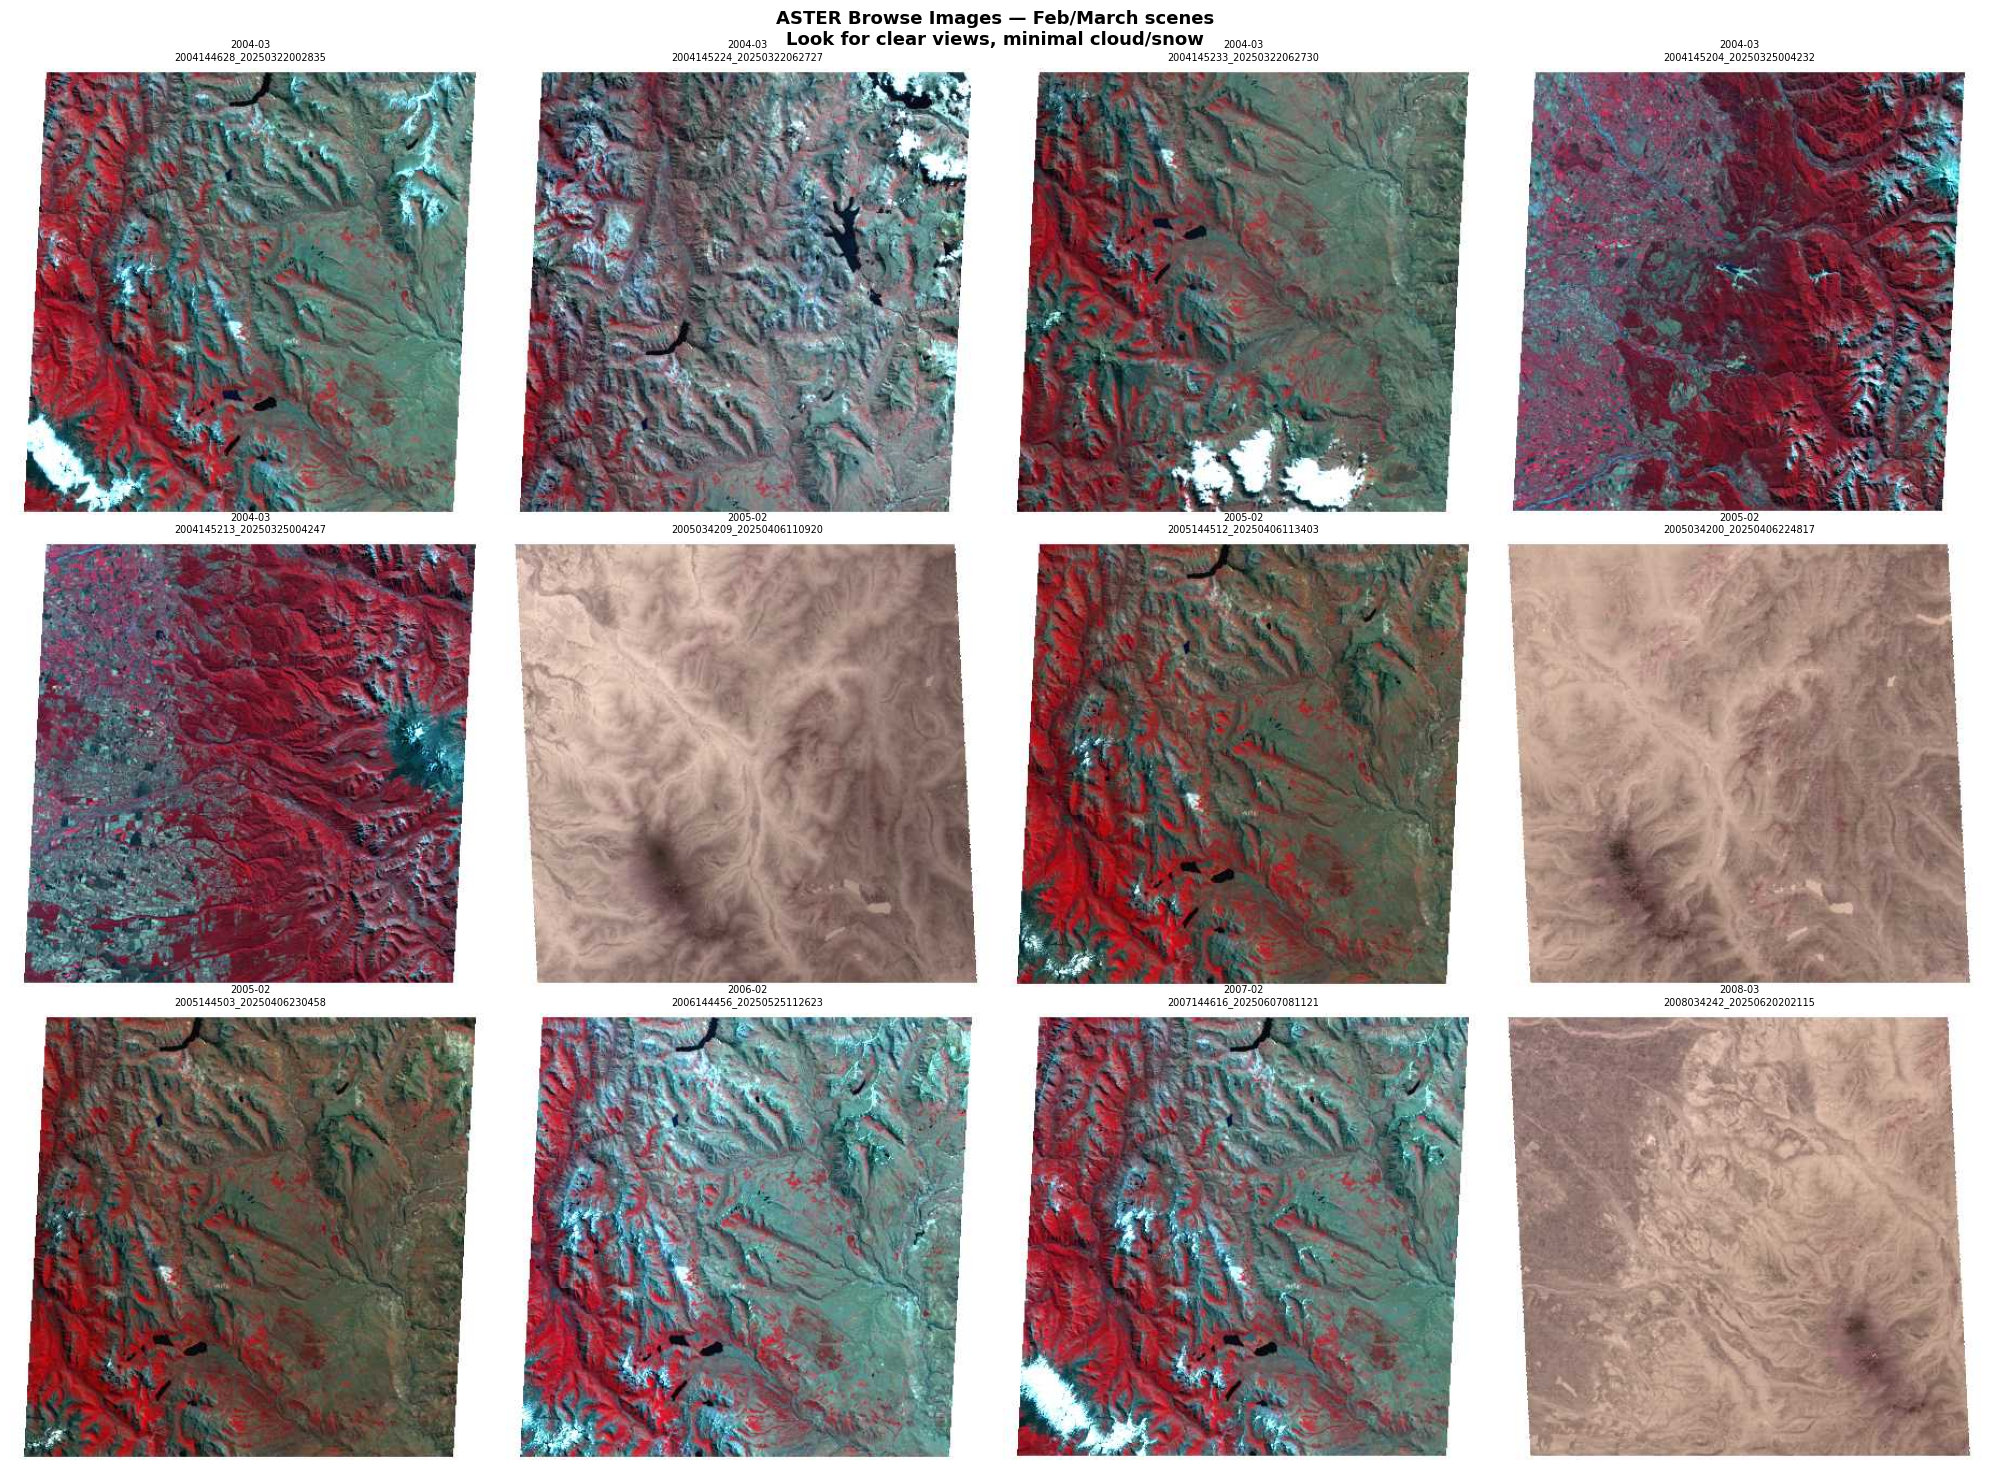

In [ ]:
from PIL import Image
import requests
import matplotlib.pyplot as plt
from io import BytesIO

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, scene in enumerate(browse_scenes[:12]):
    try:
        resp = requests.get(scene['url'], timeout=30)
        img  = Image.open(BytesIO(resp.content))
        axes[i].imshow(img)
        axes[i].set_title(f"{scene['date']}\n{scene['name'][-25:]}", fontsize=7)
        axes[i].axis('off')
    except Exception as e:
        axes[i].text(0.5, 0.5, f"{scene['date']}\nError: {e}",
                     ha='center', va='center', fontsize=7)
        axes[i].axis('off')

for j in range(12, len(axes)):
    axes[j].axis('off')

plt.suptitle('ASTER Browse Images — Feb/March scenes\nLook for clear views, minimal cloud/snow',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aster_browse_preview.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import paramiko
import os
from pathlib import Path

HOST     = "repo.sedoo.fr"
PORT     = 22
USERNAME = "ASTER_GLACIER_GUEST"
PASSWORD = "FpdSr6FegG"

# Your clean daytime Feb-March granules from the match list
target_granules = [
    "AST_L1A_00303102004145215",
    "AST_L1A_00303262004145213",
    "AST_L1A_00302182005144503",
    "AST_L1A_00302212006144456",
    "AST_L1A_00302242007144558",
    "AST_L1A_00303302008144525",
    "AST_L1A_00302112014144540",
    "AST_L1A_00302112014144558",
    "AST_L1A_00302212015145214",
    "AST_L1A_00303012018145201",
]

local_dir = Path("/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/qc_files")
local_dir.mkdir(parents=True, exist_ok=True)

transport = paramiko.Transport((HOST, PORT))
transport.connect(username=USERNAME, password=PASSWORD)
sftp = paramiko.SFTPClient.from_transport(transport)

for granule in target_granules:
    remote_path = f"/millie_chile/17_rgi60/19S/{granule}"
    granule_dir = local_dir / granule
    granule_dir.mkdir(exist_ok=True)
    
    try:
        files = sftp.listdir(remote_path)
        for f in files:
            # Download PDF and txt files only (small files)
            if f.endswith('.pdf') or f.endswith('.txt') or f.endswith('.log'):
                remote_file = f"{remote_path}/{f}"
                local_file  = granule_dir / f
                if not local_file.exists():
                    sftp.get(remote_file, str(local_file))
                    print(f"  Downloaded: {granule}/{f}")
                else:
                    print(f"  Already exists: {granule}/{f}")
    except Exception as e:
        print(f"  {granule}: error — {e}")

sftp.close()
transport.close()
print("\nDone.")

  Downloaded: AST_L1A_00303102004145215/mmaster_bias_correct_310633_error.log
  Downloaded: AST_L1A_00303102004145215/params_CrossTrack_Polynomial.txt
  Downloaded: AST_L1A_00303102004145215/params_AlongTrack_SumofSines.txt
  Downloaded: AST_L1A_00303102004145215/BiasCorrections_Results.pdf
  Downloaded: AST_L1A_00303102004145215/params_AlongTrack_Jitter.txt
  Downloaded: AST_L1A_00303102004145215/mmaster_bias_correct_310633.log
  Downloaded: AST_L1A_00303262004145213/params_CrossTrack_Polynomial.txt
  Downloaded: AST_L1A_00303262004145213/params_AlongTrack_SumofSines.txt
  Downloaded: AST_L1A_00303262004145213/BiasCorrections_Results.pdf
  Downloaded: AST_L1A_00303262004145213/params_AlongTrack_Jitter.txt
  Downloaded: AST_L1A_00303262004145213/mmaster_bias_correct_317097.log
  Downloaded: AST_L1A_00303262004145213/mmaster_bias_correct_317097_error.log
  Downloaded: AST_L1A_00302182005144503/params_CrossTrack_Polynomial.txt
  Downloaded: AST_L1A_00302182005144503/params_AlongTrack_Sum

In [ ]:
from pathlib import Path
import re
import pandas as pd

qc_dir = Path("/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/qc_files")

results = []
for granule_dir in sorted(qc_dir.iterdir()):
    if not granule_dir.is_dir():
        continue
    
    log_files = [f for f in granule_dir.iterdir() 
                 if f.suffix == '.log' and 'error' not in f.name]
    if not log_files:
        continue
    
    log_text = log_files[0].read_text(errors='replace')
    lines = log_text.strip().split('\n')
    
    # Extract all iteration lines (3 floats)
    iter_lines = []
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 3:
            try:
                vals = [float(p) for p in parts]
                iter_lines.append(vals)
            except:
                pass
    
    # First iteration = before, last = after
    if iter_lines:
        median_before = iter_lines[0][0]
        nmad_before   = iter_lines[0][2]
        median_after  = iter_lines[-1][0]
        nmad_after    = iter_lines[-1][2]
    else:
        median_before = nmad_before = median_after = nmad_after = None

    # Extract sample sizes
    orig_sample = re.search(r'Original Sample size\s*:\s*(\d+)', log_text)
    final_sample = re.search(r'Final Sample size\s*:\s*(\d+)', log_text)

    results.append({
        'granule':       granule_dir.name,
        'date':          granule_dir.name[8:16],
        'median_before': round(median_before, 2) if median_before else None,
        'nmad_before':   round(nmad_before, 2)   if nmad_before   else None,
        'median_after':  round(median_after, 2)  if median_after  else None,
        'nmad_after':    round(nmad_after, 2)    if nmad_after    else None,
        'n_orig':        int(orig_sample.group(1))  if orig_sample  else None,
        'n_final':       int(final_sample.group(1)) if final_sample else None,
    })

df_qc = pd.DataFrame(results).sort_values('nmad_after')
print(df_qc.to_string(index=False))

                  granule     date  median_before  nmad_before  median_after  nmad_after  n_orig  n_final
AST_L1A_00303102004145215 00303102          19.54        12.21         -0.39        0.03 7030300  6998489
AST_L1A_00302242007144558 00302242          -0.32        27.62          0.44        0.07 7121872  7091270
AST_L1A_00302182005144503 00302182          -4.51        16.42         -0.51        0.09 7735764  7710144
AST_L1A_00303302008144525 00303302           9.32         8.53         -0.53        0.14 7152798  7127267
AST_L1A_00303012018145201 00303012          25.55        39.35          0.58        0.17 8036832  7995123
AST_L1A_00302212006144456 00302212          -7.12        21.67          0.42        0.22 6765590  6735573
AST_L1A_00302112014144558 00302112          -8.69        21.34         -0.68        0.23 7386970  7363926
AST_L1A_00302112014144540 00302112         -17.60        24.90          0.69        0.29 7118313  7093980
AST_L1A_00302212015145214 00302212          20

In [ ]:
import paramiko
from pathlib import Path

HOST     = "repo.sedoo.fr"
PORT     = 22
USERNAME = "ASTER_GLACIER_GUEST"
PASSWORD = "FpdSr6FegG"

# All 10 granules to download
target_granules = [
    "AST_L1A_00303102004145215",
    "AST_L1A_00303262004145213",
    "AST_L1A_00302182005144503",
    "AST_L1A_00302212006144456",
    "AST_L1A_00302242007144558",
    "AST_L1A_00303302008144525",
    "AST_L1A_00302112014144540",
    "AST_L1A_00302112014144558",
    "AST_L1A_00302212015145214",
    "AST_L1A_00303012018145201",
]

local_dir = Path("/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs")
local_dir.mkdir(parents=True, exist_ok=True)

transport = paramiko.Transport((HOST, PORT))
transport.connect(username=USERNAME, password=PASSWORD)
sftp = paramiko.SFTPClient.from_transport(transport)

for granule in target_granules:
    remote_path = f"/millie_chile/17_rgi60/19S/{granule}"
    local_file  = local_dir / f"{granule}_final.zip"

    if local_file.exists():
        print(f"Already downloaded: {granule}")
        continue

    # Find the _final.zip file
    try:
        files = sftp.listdir(remote_path)
        final_zip = [f for f in files if f.endswith('_final.zip')]
        if not final_zip:
            print(f"No _final.zip found in {granule}")
            continue

        remote_file = f"{remote_path}/{final_zip[0]}"
        size_mb = sftp.stat(remote_file).st_size / 1e6
        print(f"Downloading {granule} ({size_mb:.1f} MB)...")
        sftp.get(remote_file, str(local_file))
        print(f"  Done: {local_file}")
    except Exception as e:
        print(f"  Error: {granule}: {e}")

sftp.close()
transport.close()
print("\nAll downloads complete.")

  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00303102004145215_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00303262004145213_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00302182005144503_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00302212006144456_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00302242007144558_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00303302008144525_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00302112014144540_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00302112014144558_final.zip
  Done: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/AST_L1A_00302212015145214_final.zip
  Done: /Users/milliespencer/Desktop/

In [ ]:
import zipfile
from pathlib import Path

dem_dir = Path("/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs")
extract_dir = dem_dir / "extracted"
extract_dir.mkdir(exist_ok=True)

for zip_path in sorted(dem_dir.glob("*_final.zip")):
    out_dir = extract_dir / zip_path.stem
    out_dir.mkdir(exist_ok=True)
    if any(out_dir.iterdir()):
        print(f"Already extracted: {zip_path.name}")
        continue
    print(f"Extracting: {zip_path.name}")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(out_dir)
        print(f"  Contents: {zf.namelist()}")

print("\nDone.")

Extracting: AST_L1A_00302112014144540_final.zip
  Contents: ['AST_L1A_00302112014144540_Z_adj_XAJ_final.tif', 'AST_L1A_00302112014144540_CORR_adj_final.tif']
Extracting: AST_L1A_00302112014144558_final.zip
  Contents: ['AST_L1A_00302112014144558_Z_adj_XAJ_final.tif', 'AST_L1A_00302112014144558_CORR_adj_final.tif']
Extracting: AST_L1A_00302182005144503_final.zip
  Contents: ['AST_L1A_00302182005144503_Z_adj_XAJ_final.tif', 'AST_L1A_00302182005144503_CORR_adj_final.tif']
Extracting: AST_L1A_00302212006144456_final.zip
  Contents: ['AST_L1A_00302212006144456_Z_adj_XAJ_final.tif', 'AST_L1A_00302212006144456_CORR_adj_final.tif']
Extracting: AST_L1A_00302212015145214_final.zip
  Contents: ['AST_L1A_00302212015145214_Z_adj_XAJ_final.tif', 'AST_L1A_00302212015145214_CORR_adj_final.tif']
Extracting: AST_L1A_00302242007144558_final.zip
  Contents: ['AST_L1A_00302242007144558_Z_adj_XAJ_final.tif', 'AST_L1A_00302242007144558_CORR_adj_final.tif']
Extracting: AST_L1A_00303012018145201_final.zip
  Co

In [ ]:
import rasterio
import numpy as np
from pathlib import Path

base = Path("/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/extracted")

print(f"{'Granule':<45} {'Shape':<15} {'Valid px':>10} {'Elev min':>10} {'Elev max':>10} {'Corr>40':>8}")
print("-" * 105)

for granule_dir in sorted(base.iterdir()):
    if not granule_dir.is_dir():
        continue
    
    dem_files  = list(granule_dir.glob("*_Z_adj_XAJ_final.tif"))
    corr_files = list(granule_dir.glob("*_CORR_adj_final.tif"))
    
    if not dem_files:
        continue
    
    with rasterio.open(dem_files[0]) as src:
        data = src.read(1).astype(float)
        nd = src.nodata
        if nd is not None:
            data[data == nd] = np.nan
        data[data < -500] = np.nan   # mask elevation artifacts
        data[data > 6000] = np.nan
        valid = np.sum(np.isfinite(data))
        shape = src.shape

    with rasterio.open(corr_files[0]) as src:
        corr = src.read(1).astype(float)
        corr[corr == src.nodata] = np.nan
        pct_good = np.sum(corr > 40) / np.sum(np.isfinite(corr)) * 100

    name = granule_dir.name.replace('_final', '')[:40]
    print(f"{name:<45} {str(shape):<15} {valid:>10,} "
          f"{np.nanmin(data):>10.1f} {np.nanmax(data):>10.1f} {pct_good:>7.1f}%")

Granule                                       Shape             Valid px   Elev min   Elev max  Corr>40
---------------------------------------------------------------------------------------------------------
AST_L1A_00302112014144540                     (6329, 3426)    12,235,386     -496.3     3958.4    53.5%
AST_L1A_00302112014144558                     (6330, 3418)    12,279,389     -495.0     3480.4    53.7%
AST_L1A_00302182005144503                     (6331, 3424)    12,092,117     -499.7     3454.6    53.6%
AST_L1A_00302212006144456                     (6330, 3419)    12,297,559     -499.9     5999.4    53.9%
AST_L1A_00302212015145214                     (6313, 3308)    11,829,616     -500.0     3544.5    52.3%
AST_L1A_00302242007144558                     (6328, 3424)    12,319,711     -498.4     3966.2    54.2%
AST_L1A_00303012018145201                     (6314, 3319)    12,277,494     -499.8     4123.5    56.7%
AST_L1A_00303102004145215                     (6311, 3324)    

In [ ]:
import rasterio
import numpy as np
from pathlib import Path
from rasterio.mask import mask as rio_mask
import geopandas as gpd
from shapely.geometry import box

base = Path("/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/extracted")

# Study area bounding box in UTM 19S
study_box = box(285000, 5905000, 310000, 5930000)
study_gdf = gpd.GeoDataFrame(geometry=[study_box], crs="EPSG:32719")

for name in ["AST_L1A_00302112014144540", "AST_L1A_00302112014144558"]:
    dem = list((base / f"{name}_final").glob("*_Z_adj_XAJ_final.tif"))[0]
    with rasterio.open(dem) as src:
        try:
            geoms = [study_box.__geo_interface__]
            out, _ = rio_mask(src, geoms, crop=True, nodata=np.nan)
            data = out[0].astype(float)
            data[data < -500] = np.nan
            data[data > 6000] = np.nan
            valid = np.sum(np.isfinite(data))
            print(f"{name[-20:]}: {valid:,} valid pixels over study area")
        except Exception as e:
            print(f"{name[-20:]}: no overlap — {e}")

1A_00302112014144540: 520,399 valid pixels over study area
1A_00302112014144558: 636,423 valid pixels over study area


In [ ]:
import shutil
from pathlib import Path

base     = Path("/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/DEMs/extracted")
dest_dir = Path("/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_DEMs")

# Final selection: granule → clean name
aster_dems = {
    "AST_L1A_00303102004145215": "ASTER_2004.tif",
    "AST_L1A_00303262004145213": "ASTER_2004b.tif",  # keep both 2004 scenes
    "AST_L1A_00302182005144503": "ASTER_2005.tif",
    "AST_L1A_00302212006144456": "ASTER_2006.tif",
    "AST_L1A_00302242007144558": "ASTER_2007.tif",
    "AST_L1A_00303302008144525": "ASTER_2008.tif",
    "AST_L1A_00302112014144558": "ASTER_2014.tif",  # better coverage
    "AST_L1A_00302212015145214": "ASTER_2015.tif",
    "AST_L1A_00303012018145201": "ASTER_2018.tif",
}

for granule, clean_name in aster_dems.items():
    src_path = list((base / f"{granule}_final").glob("*_Z_adj_XAJ_final.tif"))[0]
    dst_path = dest_dir / clean_name
    if dst_path.exists():
        print(f"Already exists: {clean_name}")
        continue
    shutil.copy(src_path, dst_path)
    print(f"Copied: {granule} → {clean_name}")

print("\nDone. Ready to add to Notebook 1.")

Copied: AST_L1A_00303102004145215 → ASTER_2004.tif
Copied: AST_L1A_00303262004145213 → ASTER_2004b.tif
Copied: AST_L1A_00302182005144503 → ASTER_2005.tif
Copied: AST_L1A_00302212006144456 → ASTER_2006.tif
Copied: AST_L1A_00302242007144558 → ASTER_2007.tif
Copied: AST_L1A_00303302008144525 → ASTER_2008.tif
Copied: AST_L1A_00302112014144558 → ASTER_2014.tif
Copied: AST_L1A_00302212015145214 → ASTER_2015.tif
Copied: AST_L1A_00303012018145201 → ASTER_2018.tif

Done. Ready to add to Notebook 1.
